# Part 2 - Data Visualization using dimensionality reduction

To succesfully learn from your data, you need to know it.
Dimension-reduction is a great tool to help analyze high dimensional data.
It can help us to see the data in two or three dimensions and analyze clusters or structures.
It can also be used to reduce the number of dimensions before processing the data using machine learning algorithms.
This can greatly decrease the computational load optimally without losing much information about the data.
In these tasks, you will learn how to use dimensionality reduction techniques to visualize the GalaxyMNIST dataset.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch, gzip, requests

# machine learning metrics
from sklearn import metrics

# performance metrics
from tqdm import tqdm
import time

from collections import Counter
from itertools import chain

In [2]:
from numpy.typing import NDArray

type OneDArray = np.ndarray[tuple[int]]
type TwoDArray = np.ndarray[tuple[int, int]]

In [3]:
# dataset
from galaxy_mnist import GalaxyMNIST

download_data = [
    {
        "url": "https://www.dropbox.com/scl/fi/l4ap5eq7z49l27dnfw076/train_dataset.hdf5.gz?rlkey=gjfrrrouoah0hbydbkpfx66as&st=tw6znd55&dl=1",
        "file": "train_dataset.hdf5",
    },
    {
        "url": "https://www.dropbox.com/scl/fi/ty43vhrrpa8cf8azn3awn/test_dataset.hdf5.gz?rlkey=jmlkzjiguhe271nbuzpa0njna&st=5oco8ika&dl=1",
        "file": "test_dataset.hdf5",
    },
]

root = Path("raw_galaxy_mnist")
raw = root / "GalaxyMNIST" / "raw"
raw.mkdir(parents=True, exist_ok=True)
for d in download_data:
    p = raw / d["file"]
    if not p.exists():
        r = requests.get(d["url"], timeout=60)
        p.write_bytes(gzip.decompress(r.content))

dataset = GalaxyMNIST(root=root, train=True)
val_dataset = GalaxyMNIST(root=root, train=False)

# Extract data and targets
raw_images, labels = dataset.data, dataset.targets
raw_test_images, test_labels = val_dataset.data, val_dataset.targets
label_names = dataset.classes
num_classes = len(dataset.classes)

## 2.1 Reducing Dimensions to Reduce Computational Cost


PCA scales cubically with the number of dimensions because a matrix of size `n_features x n_features` needs to be diagonalized.

- How many entries does this matrix have when using full resolution GalaxyMNIST images?

To ease the burden on your CPU, you can down-scale the data either by transforming the images to gray-scale, down-sampling the images to 32x32 resolution or doing both. We recommend going to gray-scale for powerful/newer CPUs and doing both for less powerful ones.

- Implement one of these options. You can use torchvision transforms.
- By what factor do the methods reduce the number of features and what is the expected speedup?

---

The full feature dimension is $3 \cdot 64 \cdot 64 = 12288$ leading to a matrix size of $12288^2 \approx 150.000.000$ entries.


In [4]:
# Standardize training data
raw_images_float = raw_images.float() / 255.0
train_mean = raw_images_float.mean(dim=(0, 2, 3), keepdim=True)
train_std = raw_images_float.std(dim=(0, 2, 3), keepdim=True)
images = (raw_images_float - train_mean) / train_std

The following are implementations of both transformations of the data.

We transform an image to gray-scale by combining the values of the 3 channels (RGB) in the following way:
$$Y = 0.299 R + 0.587 G + 0.114 B$$

We transform an image to a down-scaled resolution by projecting all (non-overlapping) 2x2 squares to the average of their entries.
To do this, we use matrix multiplication with the following 64x32 matrix:

$$
  P = \frac{1}{2} \begin{pmatrix}
    1 & 0 & & 0 & 0 \\
    1 & 0 & & 0 & 0 \\
    0 & 1 & & 0 & 0 \\
    0 & 1 & & 0 & 0 \\
    \vdots & \vdots & \cdots & \vdots & \vdots \\
    0 & 0 & & 1 & 0 \\
    0 & 0 & & 1 & 0 \\
    0 & 0 & & 0 & 1 \\
    0 & 0 & & 0 & 1 \\
  \end{pmatrix}
$$

If the matrix $I$ contains a raw image, then the matrix $I'$ contains the down-scaled raw image.
It is given by

$$
I' = P^{\mathsf{T}} I P.
$$


In [5]:
def get_gray_scale_of(images: torch.Tensor) -> torch.Tensor:
    """
    Transforms a single image or multiple images from RGB to gray-scale.
    It uses the following formula:

    Y = 0.299 R + 0.587 G + 0.114 B
    """
    vals = torch.tensor([0.299, 0.587, 0.114])
    return torch.einsum("c, bchw -> bhw", vals, images).unsqueeze(1)


def get_down_scale_of(images: torch.Tensor) -> torch.Tensor:
    """
    Transforms a single image or multiple images from 64x64 to 32x32 resolution.
    It does so by projecting 2x2 squares to the average of their entries.
    """
    projector = torch.tensor(
        [[1 / 2 if j == i // 2 else 0 for j in range(32)] for i in range(64)]
    )
    return torch.einsum("...hw, hi, wj -> ...ij", images, projector, projector)

Transforming to gray-scale combines the three channels into one, thereby reducing the dimension by a factor of 3.
Since PCA scales cubically with the number of dimensions, this lets us expect a speed-up factor of $3^3 = 27$.

Transforming to down-scale combines a 2-by-2 square of pixels into one, thereby reducing the dimension by a factor of $2 \times 2 = 4$.
Since PCA scales cubically with the number of dimensions, this lets us expect a speed-up factor of $4^3 = 64$.

## 2.2 Principal Component Analysis (PCA)

### 2.2.1 PCA Algorithm

- Implement the PCA algorithm. It should return the transformed data points, all principal components (eigenvectors) and all eigenvalues. Use methods like eigh for the diagonalization from numpy, scipy or torch.

---

In [6]:
ds_images = get_down_scale_of(images)
flat_ds_images = ds_images.reshape(8000, -1)


def standardize_tensor(X: torch.Tensor, dim: int | tuple[int, ...]) -> torch.Tensor:
    X_mean = X.mean(dim, keepdim=True)
    X_std = X.std(dim, keepdim=True).clamp_min(1e-8)
    return (X - X_mean) / X_std


def get_spectrum(mat: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    eigval, eigvec = (eig.flip(-1) for eig in torch.linalg.eigh(mat))
    return eigval, eigvec


def do_PCA(
    X_in: torch.Tensor, n_components: int = -1, verbose: bool = False
) -> tuple[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
    X = standardize_tensor(X_in, dim=0)
    cov = X.transpose(0, 1) @ X

    eigval, eigvec = get_spectrum(cov)
    if verbose:
        print(f"First {n_components} eigenvalues:", eigval[:n_components])
        print(f"First {n_components} eigenvectors:", eigvec[:, :n_components])

    Z = X @ eigvec[:, :n_components]

    return Z, (eigval, eigvec)

In [7]:
Z, (eigval, eigvec) = do_PCA(flat_ds_images, verbose=True)

print(f"Z =", Z)

First -1 eigenvalues: tensor([3.9036e+06, 1.0075e+06, 9.4408e+05,  ..., 4.0161e+00, 3.8282e+00,
        3.6398e+00])
First -1 eigenvectors: tensor([[ 0.0072,  0.0050, -0.0118,  ...,  0.0111,  0.0000,  0.0000],
        [ 0.0077,  0.0060, -0.0145,  ..., -0.0048, -0.0040, -0.0005],
        [ 0.0088,  0.0061, -0.0163,  ..., -0.0010,  0.0011, -0.0004],
        ...,
        [ 0.0073,  0.0099, -0.0164,  ...,  0.0012,  0.0027,  0.0031],
        [ 0.0076,  0.0079, -0.0166,  ..., -0.0013, -0.0039, -0.0008],
        [ 0.0068,  0.0059, -0.0145,  ..., -0.0009,  0.0021, -0.0033]])
Z = tensor([[ 2.2919e+00,  5.5957e+00, -5.8191e+00,  ..., -8.5922e-03,
         -8.8490e-03,  1.5192e-02],
        [-2.3449e+01,  5.3134e+00,  8.7356e+00,  ..., -4.3038e-02,
          1.7609e-02,  2.0309e-02],
        [ 1.1620e+02, -2.5777e+00, -4.5343e+01,  ...,  1.9377e-02,
         -6.7369e-03,  2.2147e-03],
        ...,
        [ 1.8567e+01, -6.6017e-01, -1.7537e+01,  ..., -7.3748e-03,
          3.0692e-04, -1.8930e-02

### 2.2.2 PCA Visualization

PCA can be used to create visualizations as well as analyze variance in the data. Use your PCA implementation to create the following plots:

- So-called scree plot, where you plot the eigenvalues against the number of components (use all eigenvalues).
- Explained variance plot, the variance explained by all components up to the n-th component divided by the total variance (use all eigenvalues).
- Dimension reduction plots. Use the data projected onto the first and second principal components to create a scatter plot. Color the points according to their true labels. Can you see which classes similar to each other from the plot? Bonus: Create a 3D plot with the first three principal components.
- Visualize the first few principal components (eigenvectors) as images. You can reshape the components to the original image dimensions and plot them.

**Bonus Note**: If you are unsure whether your implementation is correct, you may compare the principal components obtained by your implementation, $\{v_i\}_i$, with those obtained by the [scikit-learn PCA implementation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), $\{u_i\}_i$.

- _Are they completely different? Then your implementation is likely incorrect._
- _Are they equal? Then your implementation is likely correct._
- _Do some differ only in sign, i.e., $v_i = -u_i$? Then your implementation is probably correct. But why do they differ in sign?_

**_This note is intended as a sanity check and is neither necessary nor mandatory._**

---

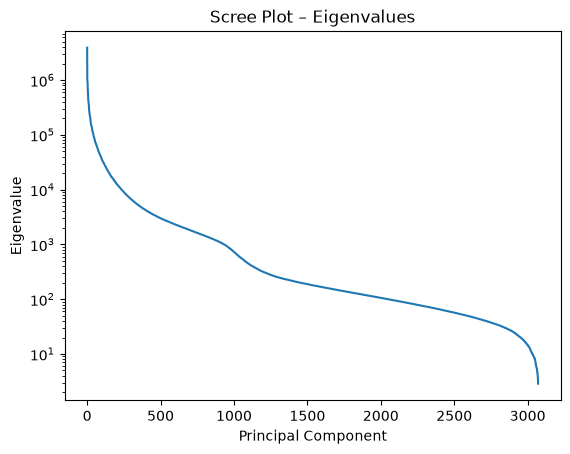

In [8]:
fig, ax = plt.subplots()

ax.plot(np.arange(len(eigval)), eigval)

ax.set_title("Scree Plot – Eigenvalues")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Eigenvalue")
ax.set_yscale("log")

plt.show(fig)

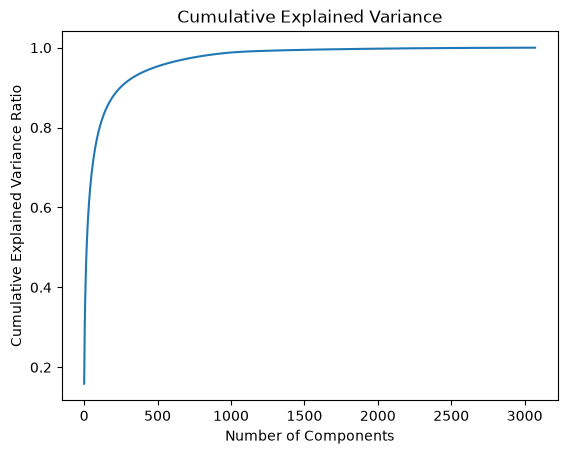

In [9]:
fig, ax = plt.subplots()

explained_variance = np.cumsum(eigval) / eigval.sum()
ax.plot(np.arange(len(explained_variance)), explained_variance)

ax.set_title("Cumulative Explained Variance")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance Ratio")

plt.show(fig)

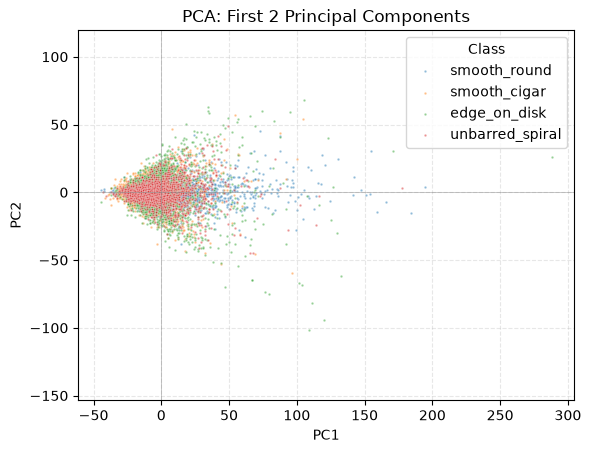

In [10]:
fig, ax = plt.subplots()

cmap = plt.get_cmap("tab10")
for i, label in enumerate(label_names):
    idx = labels == i
    ax.scatter(
        Z[idx, 0],
        Z[idx, 1],
        label=label,
        s=3,
        alpha=0.5,
        color=cmap(i),
        edgecolors="white",
        linewidths=0.3,
    )

ax.axhline(0, color="gray", linewidth=0.6, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.6, alpha=0.5)

ax.set_title("PCA: First 2 Principal Components")
ax.set_xlabel(f"PC1")
ax.set_ylabel(f"PC2")

ax.grid(True, linestyle="--", alpha=0.3)
ax.set_aspect("equal", adjustable="datalim")
ax.legend(title="Class")

plt.show()

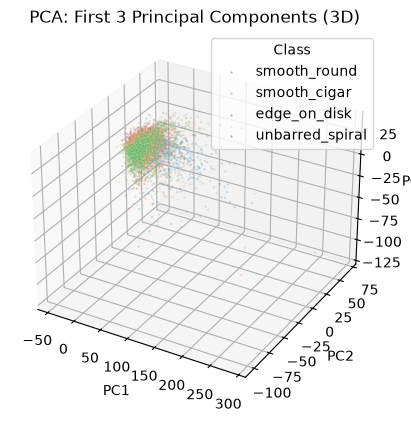

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

cmap = plt.get_cmap("tab10")
for i, label in enumerate(label_names):
    idx = labels == i
    ax.scatter(
        Z[idx, 0],
        Z[idx, 1],
        Z[idx, 2],
        label=label,
        s=3,
        alpha=0.5,
        color=cmap(i),
        edgecolors="white",
        linewidths=0.3,
    )

ax.set_title("PCA: First 3 Principal Components (3D)")
ax.set_xlabel(f"PC1")
ax.set_ylabel(f"PC2")
ax.set_zlabel(f"PC3")

ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(title="Class", loc="upper right")

plt.show(fig)

The easiest to visually identify is class 0, `smooth_round`.
It has by far the biggest extent in the direction of principal component 1.

Class 3, `unbarred_spiral`, is the next easiest to distinguish.
It is more compact along principal component 2 than the remaining classes.

In accord with the results of the confusion matrix in Part 1, class 1 and 2, `smooth_cigar` and `edge_on_disk`, are the hardest to distinguish from each other.
Maybe `smooth_cigar` are a little more extended along principal component 3.

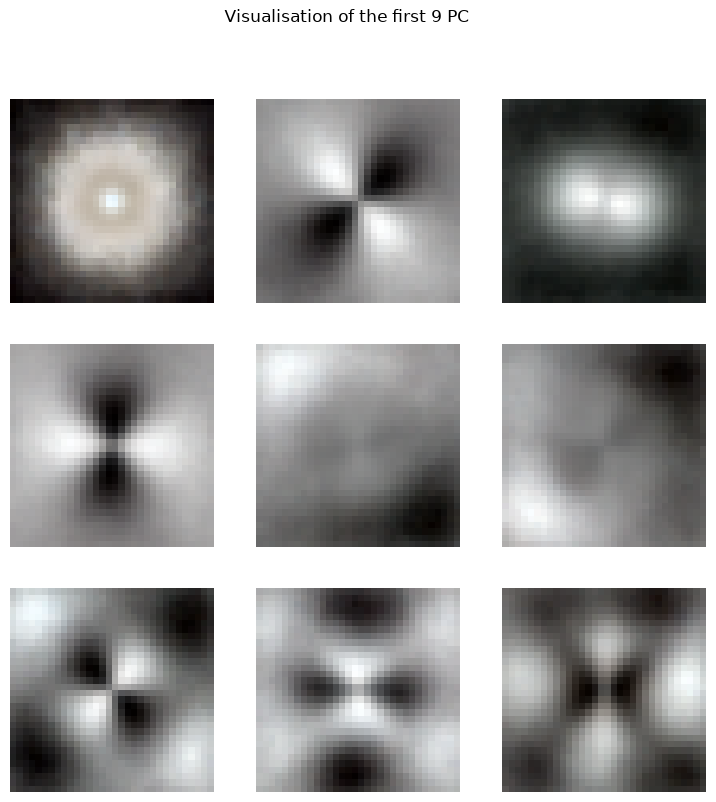

In [12]:
from Part01.visualization import show_galaxies

n_images = 9

vec = eigvec[:, :n_images].transpose(0, 1).reshape(-1, 3, 32, 32)
vec_norm = (vec - vec.amin(dim=(1, 2, 3), keepdim=True)) / (
    vec.amax(dim=(1, 2, 3), keepdim=True) - vec.amin(dim=(1, 2, 3), keepdim=True)
)

show_galaxies(vec_norm, f"Visualisation of the first {n_images} PC")

## 2.3 UMAP

Two more advanced techniques for dimensionality reduction are t-SNE and UMAP. You will now try UMAP on the GalaxyMNIST dataset.


- Briefly read about UMAP. Would a different dataset normalization yield different visualizations?
- Use UMAP to visualize the GalaxyMNIST dataset. Use the umap package, e.g. `from umap import UMAP` rather than implementing it yourself. Plot the first and second components of the UMAP projection against each other. Color the points according to their true labels.
- Play with the hyperparameters and see how they affect the visualization.

---

Yes, a different dataset normalization would yield different visualizations.
Since UMAP aims to map the high-dimensional feature space to a low-dimensional visualization space while preserving local structure, it necessarily depends highly on the distance between data points.
Different dataset normalizations would have differing impacts on the distance between points, and therefore on the visualization.

## 2.4 Identifying Regions

In your UMAP or t-SNE plot, you can probably see some specific regions.

- Choose at least two regions, identify some samples inside them plot the original images.
- What do images in the same region share?
- Bonus: Create a large image of images in the latent space. This can be done by finding the nearest neighbors in the latent space and plotting the images in a grid.
